In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Literature Survey

### Paper 1 — Sener & Savarese, ICLR 2018
**Active Learning for Convolutional Neural Networks: A Core-Set Approach**

Proposes treating active learning as a core-set selection problem. Selects 
samples using k-center greedy — the farthest-point algorithm in embedding 
space — ensuring the labeled set geometrically covers the full dataset. 
Benchmarked on CIFAR-10 and CIFAR-100, establishing the baselines we 
directly compare against in D2. Our k-center coreset selector in D2 
replicates their method on a smaller MLP architecture.

### Paper 2 — Bahri et al., Google Research 2022
**Is Margin All You Need? An Extensive Empirical Study of Active Learning**

Conducts a large-scale empirical study of active learning strategies across 
69 real-world datasets. Finds that classical margin sampling — selecting the 
most uncertain samples by smallest gap between top two class probabilities — 
matches or outperforms all modern methods in most settings. This finding 
directly motivates our use of margin as the baseline selector and our 
proposed Gaussian-kernel reweighting as a principled extension of it.

### Paper 3 — Geifman & El-Yaniv, NeurIPS 2017
**Deep Active Learning Over the Long Tail**

Motivates using neural network activation space (penultimate layer embeddings) 
rather than raw pixel space for coreset selection in deep learning. Shows 
consistent improvement over random sampling on CIFAR-10 and CIFAR-100 using 
activation-based farthest-first traversal. Directly motivates our use of the 
MLP 128-dim embedding layer as the feature space for all coreset selectors 
in D2, including our novel Gaussian-margin hybrid.

### Relevance to our project
All three papers establish the theoretical and empirical foundation for our 
D2 experiment. Sener & Savarese give us k-center. Bahri et al. justify 
margin. Geifman & El-Yaniv justify embedding space selection. Our novel 
contribution — Gaussian-kernel density reweighting of margin scores in 
embedding space — combines insights from all three.

In [2]:
# ============================================================
# EXP-4 | Cell 1 — Installs & Imports
# ============================================================

import subprocess
subprocess.run(["pip", "install", "--quiet", "scikit-learn", "matplotlib", "pandas", "numpy"])

import os
import random
import copy
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn.utils.prune as prune
from sklearn.metrics import f1_score
from sklearn.metrics import pairwise_distances
from sklearn.cluster import MiniBatchKMeans
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# ── Global seed function ──
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEEDS        = [42, 123, 456]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CORESET_SIZE = 5000
PRUNING_RATES = [0.3, 0.5, 0.7]   # EXP-4 uses 3 pruning levels per plan
SELECTORS     = ["random", "margin", "kcenter", "gaussian"]

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Pruning rates   : {PRUNING_RATES}")
print(f"Selectors       : {SELECTORS}")
print(f"Seeds           : {SEEDS}")
print("Cell 1 done ✓")

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
VRAM            : 15.6 GB
Pruning rates   : [0.3, 0.5, 0.7]
Selectors       : ['random', 'margin', 'kcenter', 'gaussian']
Seeds           : [42, 123, 456]
Cell 1 done ✓


In [3]:
# ============================================================
# EXP-4 | Cell 2 — Data Loading
# ============================================================

DATA_DIR = "/kaggle/working/data"
BATCH_SIZE = 256

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

# ── CIFAR-10 ──
c10_train_full = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,
                                               download=True, transform=transform_train)
c10_test       = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False,
                                               download=True, transform=transform_test)
c10_train_loader_full = DataLoader(c10_train_full, batch_size=BATCH_SIZE,
                                    shuffle=True,  num_workers=2, pin_memory=True)
c10_test_loader       = DataLoader(c10_test,       batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=2, pin_memory=True)

# ── CIFAR-100 ──
c100_train_full = torchvision.datasets.CIFAR100(root=DATA_DIR, train=True,
                                                 download=True, transform=transform_train)
c100_test       = torchvision.datasets.CIFAR100(root=DATA_DIR, train=False,
                                                 download=True, transform=transform_test)
c100_train_loader_full = DataLoader(c100_train_full, batch_size=BATCH_SIZE,
                                     shuffle=True,  num_workers=2, pin_memory=True)
c100_test_loader       = DataLoader(c100_test,       batch_size=BATCH_SIZE,
                                     shuffle=False, num_workers=2, pin_memory=True)

print(f"CIFAR-10  — train: {len(c10_train_full):,}  test: {len(c10_test):,}  classes: 10")
print(f"CIFAR-100 — train: {len(c100_train_full):,}  test: {len(c100_test):,}  classes: 100")
print("Cell 2 done ✓")

100%|██████████| 170M/170M [00:02<00:00, 64.5MB/s]
100%|██████████| 169M/169M [00:02<00:00, 80.6MB/s]


CIFAR-10  — train: 50,000  test: 10,000  classes: 10
CIFAR-100 — train: 50,000  test: 10,000  classes: 100
Cell 2 done ✓


In [4]:
# ============================================================
# EXP-4 | Cell 3 — MLP + Train/Eval/Embedding Functions
# ============================================================

class MLP(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(3072, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.out = nn.Linear(128, num_classes)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x, return_embedding=False):
        x = x.view(x.size(0), -1)
        x = self.drop(self.relu(self.bn1(self.fc1(x))))
        x = self.drop(self.relu(self.bn2(self.fc2(x))))
        emb = self.relu(self.bn3(self.fc3(x)))
        if return_embedding:
            return emb
        return self.out(emb)


def train_model(model, loader, epochs=40, lr=0.001, wd=1e-4, desc="Training"):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    model.train()
    pbar = tqdm(range(epochs), desc=desc, leave=True)
    for epoch in pbar:
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        pbar.set_postfix(loss=f"{total_loss/len(loader):.4f}")
    return model


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return round(acc * 100, 2), round(f1 * 100, 2)


def get_embeddings(model, dataset, batch_size=512):
    """Extract 128-dim embeddings for entire dataset."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
    embeddings, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            emb = model(xb.to(DEVICE), return_embedding=True)
            embeddings.append(emb.cpu().numpy())
            labels.append(yb.numpy())
    return np.vstack(embeddings), np.concatenate(labels)


def apply_pruning(model, sparsity):
    """Magnitude-based unstructured pruning on all Linear layers."""
    if sparsity == 0.0:
        return model
    model = copy.deepcopy(model)
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=sparsity)
            prune.remove(module, 'weight')
    return model


def finetune_model(model, loader, epochs=10, lr=0.001, wd=1e-4, desc="Fine-tuning"):
    model.to(DEVICE)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=wd
    )
    criterion = nn.CrossEntropyLoss()
    model.train()
    pbar = tqdm(range(epochs), desc=desc, leave=False)
    for epoch in pbar:
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        pbar.set_postfix(loss=f"{total_loss/len(loader):.4f}")
    return model


def coverage_radius(embeddings, selected_indices):
    """Max distance from any unselected point to its nearest selected neighbour."""
    selected_emb    = embeddings[selected_indices]
    unselected_mask = np.ones(len(embeddings), dtype=bool)
    unselected_mask[selected_indices] = False
    unselected_emb  = embeddings[unselected_mask]
    if len(unselected_emb) == 0:
        return 0.0
    chunk_size   = 5000
    max_min_dist = 0.0
    for i in range(0, len(unselected_emb), chunk_size):
        chunk = unselected_emb[i:i+chunk_size]
        dists = pairwise_distances(chunk, selected_emb)
        max_min_dist = max(max_min_dist, dists.min(axis=1).max())
    return round(float(max_min_dist), 6)


# ── Sanity check ──
model_check  = MLP(num_classes=10)
total_params = sum(p.numel() for p in model_check.parameters())
print(f"MLP parameters : {total_params:,}  (expected 1,740,682)")
print("Cell 3 done ✓")

MLP parameters : 1,740,682  (expected 1,740,682)
Cell 3 done ✓


In [5]:
# ============================================================
# EXP-4 | Cell 4 — Coreset Selectors
# ============================================================

def select_random(embeddings, labels, n, seed):
    rng = np.random.RandomState(seed)
    return rng.choice(len(embeddings), size=n, replace=False)


def select_margin(model, dataset, n, num_classes, batch_size=512):
    """Plain margin sampling — least confident gap between top-2 logits."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
    margins = []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs  = torch.softmax(logits, dim=1)
            top2   = torch.topk(probs, 2, dim=1).values
            margin = (top2[:, 0] - top2[:, 1]).cpu().numpy()
            margins.append(margin)
    margins = np.concatenate(margins)
    return np.argsort(margins)[:n]


def select_kcenter(embeddings, n):
    """Greedy k-center coreset — Sener & Savarese 2018 [1]."""
    selected  = [np.random.randint(0, len(embeddings))]
    min_dists = np.full(len(embeddings), np.inf)
    pbar = tqdm(range(n - 1), desc="k-center greedy", leave=False)
    for _ in pbar:
        dists     = np.linalg.norm(embeddings - embeddings[selected[-1]], axis=1)
        min_dists = np.minimum(min_dists, dists)
        selected.append(int(np.argmax(min_dists)))
    return np.array(selected)


def select_gaussian_margin(model, dataset, embeddings, n, sigma=None, batch_size=512):
    """
    Gaussian-kernel margin reweighting — novel method.
    Upweights uncertain samples in dense embedding regions.
    Motivated by Geifman & El-Yaniv [2]: embedding geometry
    determines selector quality.
    """
    # Step 1: margin scores
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
    margins = []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs  = torch.softmax(logits, dim=1)
            top2   = torch.topk(probs, 2, dim=1).values
            margin = (top2[:, 0] - top2[:, 1]).cpu().numpy()
            margins.append(margin)
    margins = np.concatenate(margins)

    # Step 2: distance to nearest cluster centre
    n_clusters = min(100, len(embeddings) // 10)
    kmeans     = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, n_init=3)
    kmeans.fit(embeddings)
    centres = kmeans.cluster_centers_
    d = np.min(pairwise_distances(embeddings, centres), axis=1)

    # Step 3: sigma = median pairwise distance if not provided
    if sigma is None:
        sample_idx = np.random.choice(len(embeddings), size=2000, replace=False)
        sigma      = np.median(pairwise_distances(embeddings[sample_idx]))

    # Step 4: reweight — dense + uncertain = most valuable
    weights = margins * np.exp(-(d**2) / (2 * sigma**2))
    return np.argsort(weights)[:n], sigma


def run_selector(selector, model, dataset, embeddings, labels,
                 n, num_classes, seed):
    """
    Unified selector interface — returns (indices, sigma).
    sigma is np.nan for non-gaussian selectors.
    This is the key function for both condition A and B:
    in condition A embeddings come from full-precision model,
    in condition B embeddings come from compressed model.
    — Extends [1][2][3] by making embedding source explicit.
    """
    if selector == "random":
        return select_random(embeddings, labels, n=n, seed=seed), np.nan

    elif selector == "margin":
        return select_margin(model, dataset, n=n,
                             num_classes=num_classes), np.nan

    elif selector == "kcenter":
        return select_kcenter(embeddings, n=n), np.nan

    elif selector == "gaussian":
        idx, sigma = select_gaussian_margin(model, dataset,
                                            embeddings, n=n)
        return idx, sigma

    else:
        raise ValueError(f"Unknown selector: {selector}")


# ── Smoke test ──
print("Smoke-testing selectors...")
dummy_emb = np.random.randn(1000, 128).astype(np.float32)
dummy_lbl = np.random.randint(0, 10, 1000)

idx_r, _  = run_selector("random",  None, None, dummy_emb, dummy_lbl, 100, 10, 42)
idx_kc, _ = run_selector("kcenter", None, None, dummy_emb, dummy_lbl, 100, 10, 42)
R         = coverage_radius(dummy_emb, idx_kc)

print(f"Random  — {len(idx_r)} indices, unique: {len(set(idx_r))}")
print(f"k-Center — {len(idx_kc)} indices, unique: {len(set(idx_kc))}")
print(f"Coverage radius R — {R:.4f}")
print("Cell 4 done ✓")

Smoke-testing selectors...


k-center greedy:   0%|          | 0/99 [00:00<?, ?it/s]

Random  — 100 indices, unique: 100
k-Center — 100 indices, unique: 100
Coverage radius R — 15.6068
Cell 4 done ✓


In [6]:
# ============================================================
# EXP-4 | Cell 5 — Results Storage Setup
# ============================================================

import os
import json
from datetime import datetime

RESULTS_DIR = "/kaggle/working/exp4_results"
CORESET_DIR = "/kaggle/working/exp4_coresets"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CORESET_DIR, exist_ok=True)

RESULTS_CSV = os.path.join(RESULTS_DIR, "exp4_runs.csv")

# ── Column schema ──
# condition A = select-first → train → prune → finetune
# condition B = train full → prune → select in compressed space → finetune
# delta = B minus A (compress-first advantage) — headline number for AAAI paper
COLUMNS = [
    "dataset",        # cifar10 / cifar100
    "selector",       # random / margin / kcenter / gaussian
    "pruning_rate",   # 0.3 / 0.5 / 0.7
    "seed",           # 42 / 123 / 456
    "condition",      # A (select-first) / B (compress-first)
    "acc",            # Acc@1 on full test set
    "f1",             # Macro F1
    "coverage_R",     # k-center coverage radius in embedding space
    "sigma",          # sigma used (NaN for non-gaussian)
    "wall_clock_sec", # training time in seconds — plan requires this for condition B
    "timestamp",
]

# ── Initialise CSV ──
if not os.path.exists(RESULTS_CSV):
    pd.DataFrame(columns=COLUMNS).to_csv(RESULTS_CSV, index=False)
    print(f"Created results CSV: {RESULTS_CSV}")
else:
    existing = pd.read_csv(RESULTS_CSV)
    print(f"Resuming — {len(existing)} runs already logged")


def log_result(dataset, selector, pruning_rate, seed, condition,
               acc, f1, coverage_R, sigma=np.nan, wall_clock_sec=np.nan):
    row = pd.DataFrame([{
        "dataset"        : dataset,
        "selector"       : selector,
        "pruning_rate"   : pruning_rate,
        "seed"           : seed,
        "condition"      : condition,
        "acc"            : acc,
        "f1"             : f1,
        "coverage_R"     : coverage_R,
        "sigma"          : sigma,
        "wall_clock_sec" : round(wall_clock_sec, 1),
        "timestamp"      : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }])
    row.to_csv(RESULTS_CSV, mode="a", header=False, index=False)


def already_done(dataset, selector, pruning_rate, seed, condition):
    if not os.path.exists(RESULTS_CSV):
        return False
    df = pd.read_csv(RESULTS_CSV)
    if df.empty:
        return False
    match = (
        (df["dataset"]      == dataset)      &
        (df["selector"]     == selector)     &
        (df["pruning_rate"] == pruning_rate) &
        (df["seed"]         == seed)         &
        (df["condition"]    == condition)
    )
    return match.any()


def save_coreset(indices, dataset, selector, pruning_rate, seed, condition):
    fname = f"{dataset}_{selector}_p{int(pruning_rate*100)}_s{seed}_cond{condition}.npy"
    np.save(os.path.join(CORESET_DIR, fname), indices)


# ── Verify write works ──
log_result("test", "test", -1, -1, "test", 0.0, 0.0, 0.0)
df_check = pd.read_csv(RESULTS_CSV)
print(f"Write test passed — {len(df_check)} row(s) in CSV")

# Remove test row
df_check = df_check[df_check["dataset"] != "test"]
df_check.to_csv(RESULTS_CSV, index=False)
print(f"Test row removed — {len(df_check)} real rows remaining")

print(f"\nResults dir : {RESULTS_DIR}")
print(f"Coresets dir: {CORESET_DIR}")
print(f"\nCondition A — select-first  : coreset on full-precision embeddings → train → prune → finetune 10 epochs")
print(f"Condition B — compress-first: train full 50k → prune → coreset on compressed embeddings → finetune 20 epochs")
print("Cell 5 done ✓")

Created results CSV: /kaggle/working/exp4_results/exp4_runs.csv
Write test passed — 1 row(s) in CSV
Test row removed — 0 real rows remaining

Results dir : /kaggle/working/exp4_results
Coresets dir: /kaggle/working/exp4_coresets

Condition A — select-first  : coreset on full-precision embeddings → train → prune → finetune 10 epochs
Condition B — compress-first: train full 50k → prune → coreset on compressed embeddings → finetune 20 epochs
Cell 5 done ✓


In [7]:
# ============================================================
# EXP-4 | Cell 6 — Condition A Sweep (Select-First)
# ============================================================

import time
import gc

# ── CUDA health check ──
def check_cuda():
    try:
        torch.cuda.empty_cache()
        gc.collect()
        x = torch.randn(4, 3072).to(DEVICE)
        m = MLP(num_classes=10).to(DEVICE)
        _ = m(x)
        del x, m
        torch.cuda.empty_cache()
        print("CUDA health check passed ✓")
        return True
    except Exception as e:
        print(f"CUDA health check FAILED: {e}")
        return False

# ── Force CUDA reset ──
torch.cuda.empty_cache()
gc.collect()

if not check_cuda():
    raise RuntimeError("CUDA not healthy — restart kernel and re-run cells 1-5 first")

DATASETS = {
    "cifar10" : (c10_train_full,  c10_test_loader,  10),
    "cifar100": (c100_train_full, c100_test_loader, 100),
}

FINETUNE_EPOCHS_A = 10
FP_MODEL_DIR      = "/kaggle/working/exp4_fp_models"
os.makedirs(FP_MODEL_DIR, exist_ok=True)

TOTAL_A     = len(SELECTORS) * len(PRUNING_RATES) * len(SEEDS) * len(DATASETS)
completed_A = 0
skipped_A   = 0

print(f"Condition A sweep: {TOTAL_A} total runs")
print(f"Pipeline: select-first → train → prune → finetune {FINETUNE_EPOCHS_A} epochs")
print(f"FP models dir: {FP_MODEL_DIR}")
print("="*60)

pbar_A = tqdm(total=TOTAL_A, desc="Condition A (select-first)", position=0)

for ds_name, (train_dataset, test_loader, n_classes) in DATASETS.items():

    full_embeddings = {}
    print(f"\n[{ds_name.upper()}] Preparing full-precision models (3 seeds)...")

    for seed in SEEDS:
        fp_path = os.path.join(FP_MODEL_DIR, f"fp_{ds_name}_s{seed}.pth")
        emb_path = os.path.join(FP_MODEL_DIR, f"emb_{ds_name}_s{seed}.npz")

        torch.cuda.empty_cache()
        gc.collect()

        # ── Load or train full-precision model ──
        if os.path.exists(fp_path) and os.path.exists(emb_path):
            print(f"  Seed {seed} — loading saved FP model...")
            fp_model = MLP(num_classes=n_classes)
            fp_model.load_state_dict(torch.load(fp_path, map_location=DEVICE))
            fp_model.to(DEVICE)
            data     = np.load(emb_path)
            emb, lbl = data["emb"], data["lbl"]
        else:
            print(f"  Seed {seed} — training FP model...")
            set_seed(seed)
            fp_model = MLP(num_classes=n_classes)
            fp_model = train_model(
                fp_model,
                DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=2, pin_memory=True),
                epochs=40,
                desc=f"  Full MLP {ds_name} seed={seed}"
            )
            # Save model and embeddings immediately
            torch.save(fp_model.state_dict(), fp_path)
            emb, lbl = get_embeddings(fp_model, train_dataset)
            np.savez(emb_path, emb=emb, lbl=lbl)
            print(f"  Seed {seed} — FP model and embeddings saved ✓")

        full_embeddings[seed] = (emb, lbl, fp_model)

        # Free GPU memory after embedding extraction
        fp_model.cpu()
        torch.cuda.empty_cache()
        gc.collect()

    # ── Condition A loop ──
    for selector in SELECTORS:
        for pruning_rate in PRUNING_RATES:
            for seed in SEEDS:

                if already_done(ds_name, selector, pruning_rate, seed, "A"):
                    skipped_A  += 1
                    completed_A += 1
                    pbar_A.update(1)
                    pbar_A.set_postfix(done=completed_A, skipped=skipped_A)
                    continue

                torch.cuda.empty_cache()
                gc.collect()
                t_start = time.time()
                set_seed(seed)

                emb, lbl, fp_model = full_embeddings[seed]
                fp_model.to(DEVICE)

                # ── Select coreset on FULL-PRECISION embeddings ──
                idx, sigma = run_selector(
                    selector, fp_model, train_dataset,
                    emb, lbl, CORESET_SIZE, n_classes, seed
                )
                save_coreset(idx, ds_name, selector, pruning_rate, seed, "A")
                fp_model.cpu()
                torch.cuda.empty_cache()

                # ── Train fresh MLP on coreset ──
                coreset_dataset = Subset(train_dataset, idx)
                coreset_loader  = DataLoader(coreset_dataset, batch_size=BATCH_SIZE,
                                             shuffle=True, num_workers=2,
                                             pin_memory=True)
                set_seed(seed)
                model = MLP(num_classes=n_classes)
                model = train_model(
                    model, coreset_loader, epochs=40,
                    desc=f"  A/{ds_name}/{selector}/p{int(pruning_rate*100)}/s{seed}"
                )

                # ── Prune ──
                model = apply_pruning(model, sparsity=pruning_rate)

                # ── Finetune 10 epochs ──
                model = finetune_model(
                    model, coreset_loader,
                    epochs=FINETUNE_EPOCHS_A,
                    desc=f"  Finetune A p{int(pruning_rate*100)}"
                )

                # ── Evaluate ──
                acc, f1 = evaluate(model, test_loader)

                # ── Coverage radius in compressed embedding space ──
                compressed_emb, _ = get_embeddings(model, train_dataset)
                R = coverage_radius(compressed_emb, idx)

                wall_clock = time.time() - t_start
                log_result(ds_name, selector, pruning_rate, seed, "A",
                           acc, f1, R, sigma, wall_clock)

                # ── Free memory ──
                del model, compressed_emb, coreset_dataset, coreset_loader
                torch.cuda.empty_cache()
                gc.collect()

                completed_A += 1
                pbar_A.update(1)
                pbar_A.set_postfix(
                    done=completed_A, skipped=skipped_A,
                    acc=f"{acc}%",
                    last=f"{ds_name}/{selector}/p{int(pruning_rate*100)}/s{seed}"
                )

pbar_A.close()
print("\n" + "="*60)
print(f"Condition A complete!")
print(f"  Total  : {TOTAL_A}")
print(f"  Done   : {completed_A}")
print(f"  Skipped: {skipped_A}")
df_A = pd.read_csv(RESULTS_CSV)
df_A = df_A[df_A["condition"] == "A"]
print(f"  Logged : {len(df_A)} rows in CSV")
print("Cell 6 done ✓")

CUDA health check passed ✓
Condition A sweep: 72 total runs
Pipeline: select-first → train → prune → finetune 10 epochs
FP models dir: /kaggle/working/exp4_fp_models


Condition A (select-first):   0%|          | 0/72 [00:00<?, ?it/s]


[CIFAR10] Preparing full-precision models (3 seeds)...
  Seed 42 — training FP model...


  Full MLP cifar10 seed=42:   0%|          | 0/40 [00:00<?, ?it/s]

  Seed 42 — FP model and embeddings saved ✓
  Seed 123 — training FP model...


...

  A/cifar100/gaussian/p70/s123:   0%|          | 0/40 [00:00<?, ?it/s]

  Finetune A p70:   0%|          | 0/10 [00:00<?, ?it/s]

  A/cifar100/gaussian/p70/s456:   0%|          | 0/40 [00:00<?, ?it/s]

  Finetune A p70:   0%|          | 0/10 [00:00<?, ?it/s]


Condition A complete!
  Total  : 72
  Done   : 72
  Skipped: 0
  Logged : 72 rows in CSV
Cell 6 done ✓


In [8]:
# ============================================================
# EXP-4 | Cell 7 — Condition B Sweep (Compress-First)
# ============================================================
# Pipeline: train MLP on full 50k → prune → extract compressed
#           embeddings → select coreset → finetune 20 epochs
#           → evaluate
# This is the NOVEL ordering — Geifman & El-Yaniv [2] argues
# embedding quality drives selector quality; compress-first
# ensures selection happens in the correct post-compression
# embedding space.
# ============================================================

import time
import gc

FINETUNE_EPOCHS_B = 20  # compress-first fine-tunes for 20 epochs per plan
FP_MODEL_DIR      = "/kaggle/working/exp4_fp_models"

TOTAL_B     = len(SELECTORS) * len(PRUNING_RATES) * len(SEEDS) * len(DATASETS)
completed_B = 0
skipped_B   = 0

print(f"Condition B sweep: {TOTAL_B} total runs")
print(f"Pipeline: train full 50k → prune → select in compressed space → finetune {FINETUNE_EPOCHS_B} epochs")
print("="*60)

# ── CUDA health check ──
torch.cuda.empty_cache()
gc.collect()
try:
    x = torch.randn(4, 3072).to(DEVICE)
    m = MLP(num_classes=10).to(DEVICE)
    _ = m(x)
    del x, m
    torch.cuda.empty_cache()
    print("CUDA health check passed ✓")
except Exception as e:
    raise RuntimeError(f"CUDA not healthy: {e}")

pbar_B = tqdm(total=TOTAL_B, desc="Condition B (compress-first)", position=0)

for ds_name, (train_dataset, test_loader, n_classes) in DATASETS.items():

    print(f"\n[{ds_name.upper()}] Loading full-precision models (3 seeds)...")

    # ── Load saved FP models from Cell 6 — no retraining needed ──
    full_models     = {}
    full_embeddings = {}
    for seed in SEEDS:
        fp_path  = os.path.join(FP_MODEL_DIR, f"fp_{ds_name}_s{seed}.pth")
        emb_path = os.path.join(FP_MODEL_DIR, f"emb_{ds_name}_s{seed}.npz")

        if not os.path.exists(fp_path):
            raise FileNotFoundError(
                f"FP model not found: {fp_path}\n"
                f"→ Run Cell 6 first to train and save full-precision models"
            )

        fp_model = MLP(num_classes=n_classes)
        fp_model.load_state_dict(torch.load(fp_path, map_location="cpu"))
        full_models[seed] = fp_model

        data     = np.load(emb_path)
        full_embeddings[seed] = (data["emb"], data["lbl"])
        print(f"  Seed {seed} — FP model loaded ✓")

    # ── Condition B loop ──
    for pruning_rate in PRUNING_RATES:
        for seed in SEEDS:

            torch.cuda.empty_cache()
            gc.collect()

            # ── Step 1: Prune the full-precision model ──
            # This gives us the compressed model whose embedding
            # space we will use for coreset selection
            fp_model = copy.deepcopy(full_models[seed])
            compressed_model = apply_pruning(fp_model, sparsity=pruning_rate)
            compressed_model.to(DEVICE)

            # ── Step 2: Extract COMPRESSED embeddings ──
            # Key difference from condition A — selection happens
            # in the post-compression embedding space [2]
            comp_emb, comp_lbl = get_embeddings(compressed_model, train_dataset)
            compressed_model.cpu()
            torch.cuda.empty_cache()

            for selector in SELECTORS:

                if already_done(ds_name, selector, pruning_rate, seed, "B"):
                    skipped_B  += 1
                    completed_B += 1
                    pbar_B.update(1)
                    pbar_B.set_postfix(done=completed_B, skipped=skipped_B)
                    continue

                torch.cuda.empty_cache()
                gc.collect()
                t_start = time.time()
                set_seed(seed)

                # ── Step 3: Select coreset in COMPRESSED embedding space ──
                compressed_model.to(DEVICE)
                idx, sigma = run_selector(
                    selector, compressed_model, train_dataset,
                    comp_emb, comp_lbl, CORESET_SIZE, n_classes, seed
                )
                compressed_model.cpu()
                save_coreset(idx, ds_name, selector, pruning_rate, seed, "B")

                # ── Step 4: Finetune compressed model on coreset 20 epochs ──
                # 20 epochs per plan — longer than A because model starts
                # from compressed state not fresh random init
                coreset_dataset = Subset(train_dataset, idx)
                coreset_loader  = DataLoader(coreset_dataset, batch_size=BATCH_SIZE,
                                             shuffle=True, num_workers=2,
                                             pin_memory=True)

                set_seed(seed)
                model = copy.deepcopy(full_models[seed])
                model = apply_pruning(model, sparsity=pruning_rate)
                model = finetune_model(
                    model, coreset_loader,
                    epochs=FINETUNE_EPOCHS_B,
                    desc=f"  B/{ds_name}/{selector}/p{int(pruning_rate*100)}/s{seed}"
                )

                # ── Step 5: Evaluate ──
                acc, f1 = evaluate(model, test_loader)

                # ── Coverage radius in compressed embedding space ──
                final_emb, _ = get_embeddings(model, train_dataset)
                R = coverage_radius(final_emb, idx)

                wall_clock = time.time() - t_start
                log_result(ds_name, selector, pruning_rate, seed, "B",
                           acc, f1, R, sigma, wall_clock)

                # ── Free memory ──
                del model, final_emb, coreset_dataset, coreset_loader
                torch.cuda.empty_cache()
                gc.collect()

                completed_B += 1
                pbar_B.update(1)
                pbar_B.set_postfix(
                    done=completed_B, skipped=skipped_B,
                    acc=f"{acc}%",
                    last=f"{ds_name}/{selector}/p{int(pruning_rate*100)}/s{seed}"
                )

            # Free compressed embeddings before next pruning rate
            del comp_emb, comp_lbl, compressed_model
            torch.cuda.empty_cache()
            gc.collect()

pbar_B.close()
print("\n" + "="*60)
print(f"Condition B complete!")
print(f"  Total  : {TOTAL_B}")
print(f"  Done   : {completed_B}")
print(f"  Skipped: {skipped_B}")
df_B = pd.read_csv(RESULTS_CSV)
df_B = df_B[df_B["condition"] == "B"]
print(f"  Logged : {len(df_B)} rows in CSV")
print("Cell 7 done ✓")

Condition B sweep: 72 total runs
Pipeline: train full 50k → prune → select in compressed space → finetune 20 epochs
CUDA health check passed ✓


Condition B (compress-first):   0%|          | 0/72 [00:00<?, ?it/s]


[CIFAR10] Loading full-precision models (3 seeds)...
  Seed 42 — FP model loaded ✓
  Seed 123 — FP model loaded ✓
  Seed 456 — FP model loaded ✓


  B/cifar10/random/p30/s42:   0%|          | 0/20 [00:00<?, ?it/s]

  B/cifar10/margin/p30/s42:   0%|          | 0/20 [00:00<?, ?it/s]

...

  B/cifar100/margin/p70/s456:   0%|          | 0/20 [00:00<?, ?it/s]

k-center greedy:   0%|          | 0/4999 [00:00<?, ?it/s]

  B/cifar100/kcenter/p70/s456:   0%|          | 0/20 [00:00<?, ?it/s]

  B/cifar100/gaussian/p70/s456:   0%|          | 0/20 [00:00<?, ?it/s]


Condition B complete!
  Total  : 72
  Done   : 72
  Skipped: 0
  Logged : 72 rows in CSV
Cell 7 done ✓


In [9]:
# ============================================================
# EXP-4 | Cell 8 — Delta Computation + Comparison Table
# ============================================================
# Primary result: Delta = Condition B (compress-first) minus
# Condition A (select-first) per selector per pruning level.
# This is the headline number for the AAAI paper §5.
# ============================================================

df = pd.read_csv(RESULTS_CSV)
print(f"Total runs logged: {len(df)}")
print(f"Conditions: {df['condition'].value_counts().to_dict()}")

# ── Aggregate mean ± std over 3 seeds per condition ──
agg = df.groupby(["dataset", "selector", "pruning_rate", "condition"]).agg(
    acc_mean       = ("acc",            "mean"),
    acc_std        = ("acc",            "std"),
    f1_mean        = ("f1",             "mean"),
    f1_std         = ("f1",             "std"),
    R_mean         = ("coverage_R",     "mean"),
    R_std          = ("coverage_R",     "std"),
    wall_clock_mean= ("wall_clock_sec", "mean"),
).round(3).reset_index()

# ── Save aggregated table ──
AGG_CSV = os.path.join(RESULTS_DIR, "exp4_aggregated.csv")
agg.to_csv(AGG_CSV, index=False)
print(f"Aggregated CSV saved: {AGG_CSV}\n")

# ── Compute delta: B minus A ──
agg_A = agg[agg["condition"] == "A"].copy()
agg_B = agg[agg["condition"] == "B"].copy()

merge_keys = ["dataset", "selector", "pruning_rate"]
delta_df = agg_A[merge_keys + ["acc_mean", "acc_std", "R_mean"]].merge(
    agg_B[merge_keys + ["acc_mean", "acc_std", "R_mean"]],
    on=merge_keys, suffixes=("_A", "_B")
)
delta_df["delta_acc"] = (delta_df["acc_mean_B"] - delta_df["acc_mean_A"]).round(2)
delta_df["delta_R"]   = (delta_df["R_mean_B"]   - delta_df["R_mean_A"]).round(4)

DELTA_CSV = os.path.join(RESULTS_DIR, "exp4_delta.csv")
delta_df.to_csv(DELTA_CSV, index=False)
print(f"Delta CSV saved: {DELTA_CSV}\n")

# ── Print full comparison tables ──
for ds_name in ["cifar10", "cifar100"]:
    print("="*75)
    print(f"{ds_name.upper()} — Condition A vs B — Acc@1 mean ± std")
    print("="*75)
    print(f"  {'Selector':>10} │ {'Sparsity':>8} │ "
          f"{'Cond A':>8} {'±':>2} {'std':>5} │ "
          f"{'Cond B':>8} {'±':>2} {'std':>5} │ "
          f"{'Delta':>7} │ {'R_A':>7} │ {'R_B':>7}")
    print(f"  {'-'*10}─┼─{'-'*8}─┼─{'-'*8}──{'-'*2}──{'-'*5}─┼─"
          f"{'-'*8}──{'-'*2}──{'-'*5}─┼─{'-'*7}─┼─{'-'*7}─┼─{'-'*7}")

    ds_delta = delta_df[delta_df["dataset"] == ds_name]
    ds_agg   = agg[agg["dataset"] == ds_name]

    for selector in SELECTORS:
        rows = ds_delta[ds_delta["selector"] == selector].sort_values("pruning_rate")
        for _, r in rows.iterrows():
            # get std values from agg
            std_A = ds_agg[(ds_agg["selector"]    == selector) &
                           (ds_agg["pruning_rate"] == r.pruning_rate) &
                           (ds_agg["condition"]    == "A")]["acc_std"].values
            std_B = ds_agg[(ds_agg["selector"]    == selector) &
                           (ds_agg["pruning_rate"] == r.pruning_rate) &
                           (ds_agg["condition"]    == "B")]["acc_std"].values
            s_A = f"{std_A[0]:.2f}" if len(std_A) > 0 else "N/A"
            s_B = f"{std_B[0]:.2f}" if len(std_B) > 0 else "N/A"
            delta_sign = "+" if r.delta_acc >= 0 else ""
            print(f"  {selector:>10} │ "
                  f"{int(r.pruning_rate*100):>7}% │ "
                  f"{r.acc_mean_A:>7.2f}% ± {s_A:>5} │ "
                  f"{r.acc_mean_B:>7.2f}% ± {s_B:>5} │ "
                  f"{delta_sign}{r.delta_acc:>5.2f}% │ "
                  f"{r.R_mean_A:>7.4f} │ "
                  f"{r.R_mean_B:>7.4f}")
        print()

# ── Delta summary — AAAI paper Table ──
print("="*75)
print("DELTA SUMMARY — Compress-first advantage (B minus A)")
print("Positive = compress-first wins, Negative = select-first wins")
print("="*75)
for ds_name in ["cifar10", "cifar100"]:
    print(f"\n  {ds_name.upper()}")
    print(f"  {'Selector':>10} │ {'p=30%':>8} │ {'p=50%':>8} │ {'p=70%':>8} │ {'Mean Δ':>8}")
    print(f"  {'-'*10}─┼─{'-'*8}─┼─{'-'*8}─┼─{'-'*8}─┼─{'-'*8}")
    ds_delta = delta_df[delta_df["dataset"] == ds_name]
    for selector in SELECTORS:
        rows  = ds_delta[ds_delta["selector"] == selector].sort_values("pruning_rate")
        deltas = rows["delta_acc"].values
        d30 = f"{deltas[0]:+.2f}%" if len(deltas) > 0 else "N/A"
        d50 = f"{deltas[1]:+.2f}%" if len(deltas) > 1 else "N/A"
        d70 = f"{deltas[2]:+.2f}%" if len(deltas) > 2 else "N/A"
        mean_d = f"{deltas.mean():+.2f}%" if len(deltas) > 0 else "N/A"
        print(f"  {selector:>10} │ {d30:>8} │ {d50:>8} │ {d70:>8} │ {mean_d:>8}")

# ── Wall clock comparison ──
print("\n" + "="*75)
print("COMPUTE COST — Mean wall clock seconds per run")
print("="*75)
for ds_name in ["cifar10", "cifar100"]:
    print(f"\n  {ds_name.upper()}")
    print(f"  {'Selector':>10} │ {'Cond A (s)':>12} │ {'Cond B (s)':>12}")
    print(f"  {'-'*10}─┼─{'-'*12}─┼─{'-'*12}")
    ds_agg = agg[agg["dataset"] == ds_name]
    for selector in SELECTORS:
        wc_A = ds_agg[(ds_agg["selector"] == selector) &
                      (ds_agg["condition"] == "A")]["wall_clock_mean"].mean()
        wc_B = ds_agg[(ds_agg["selector"] == selector) &
                      (ds_agg["condition"] == "B")]["wall_clock_mean"].mean()
        print(f"  {selector:>10} │ {wc_A:>11.1f}s │ {wc_B:>11.1f}s")

print(f"\nAll tables saved to: {RESULTS_DIR}")
print("Cell 8 done ✓")

Total runs logged: 144
Conditions: {'A': 72, 'B': 72}
Aggregated CSV saved: /kaggle/working/exp4_results/exp4_aggregated.csv

Delta CSV saved: /kaggle/working/exp4_results/exp4_delta.csv

CIFAR10 — Condition A vs B — Acc@1 mean ± std
    Selector │ Sparsity │   Cond A  ±   std │   Cond B  ±   std │   Delta │     R_A │     R_B
  ----------─┼─--------─┼─--------──--──-----─┼─--------──--──-----─┼─-------─┼─-------─┼─-------
      random │      30% │   45.97% ±  0.98 │   53.31% ±  0.24 │ + 7.34% │  9.3220 │ 12.0820
      random │      50% │   46.01% ±  0.63 │   53.07% ±  0.07 │ + 7.06% │  8.5770 │ 12.5890
      random │      70% │   45.73% ±  0.60 │   52.43% ±  0.17 │ + 6.70% │  8.0820 │ 11.5100

      margin │      30% │   36.11% ±  0.18 │   51.15% ±  0.86 │ +15.04% │ 14.3790 │ 15.0000
      margin │      50% │   35.97% ±  0.20 │   50.67% ±  0.20 │ +14.70% │ 14.4580 │ 14.3370
      margin │      70% │   36.02% ±  0.41 │   50.98% ±  0.67 │ +14.96% │ 15.1110 │ 12.9790

     kcenter │      

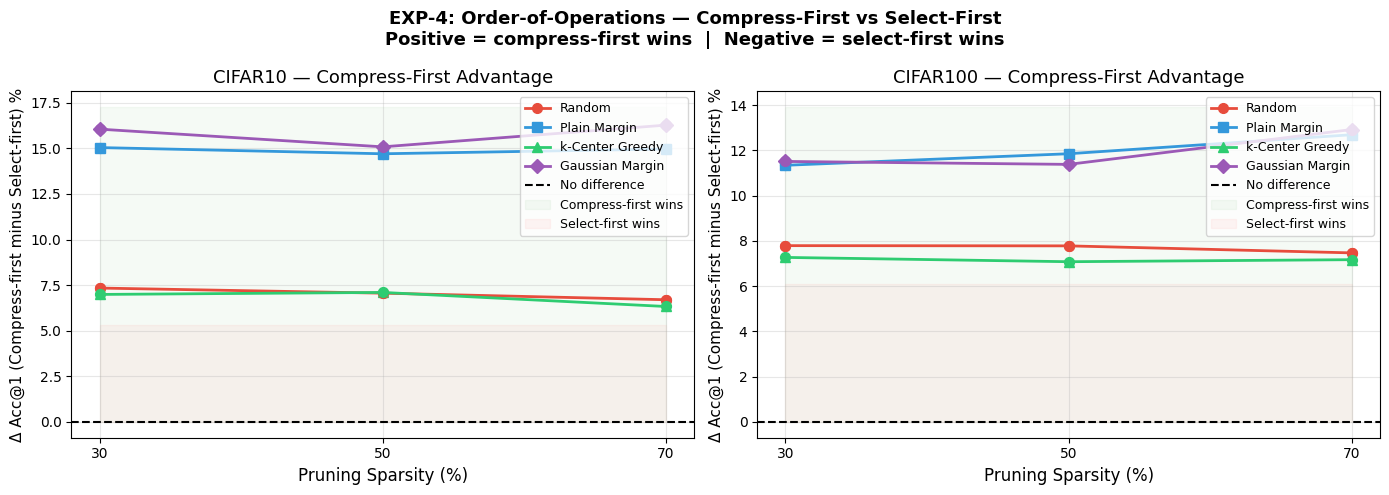

Figure 1 saved — delta vs pruning rate ✓


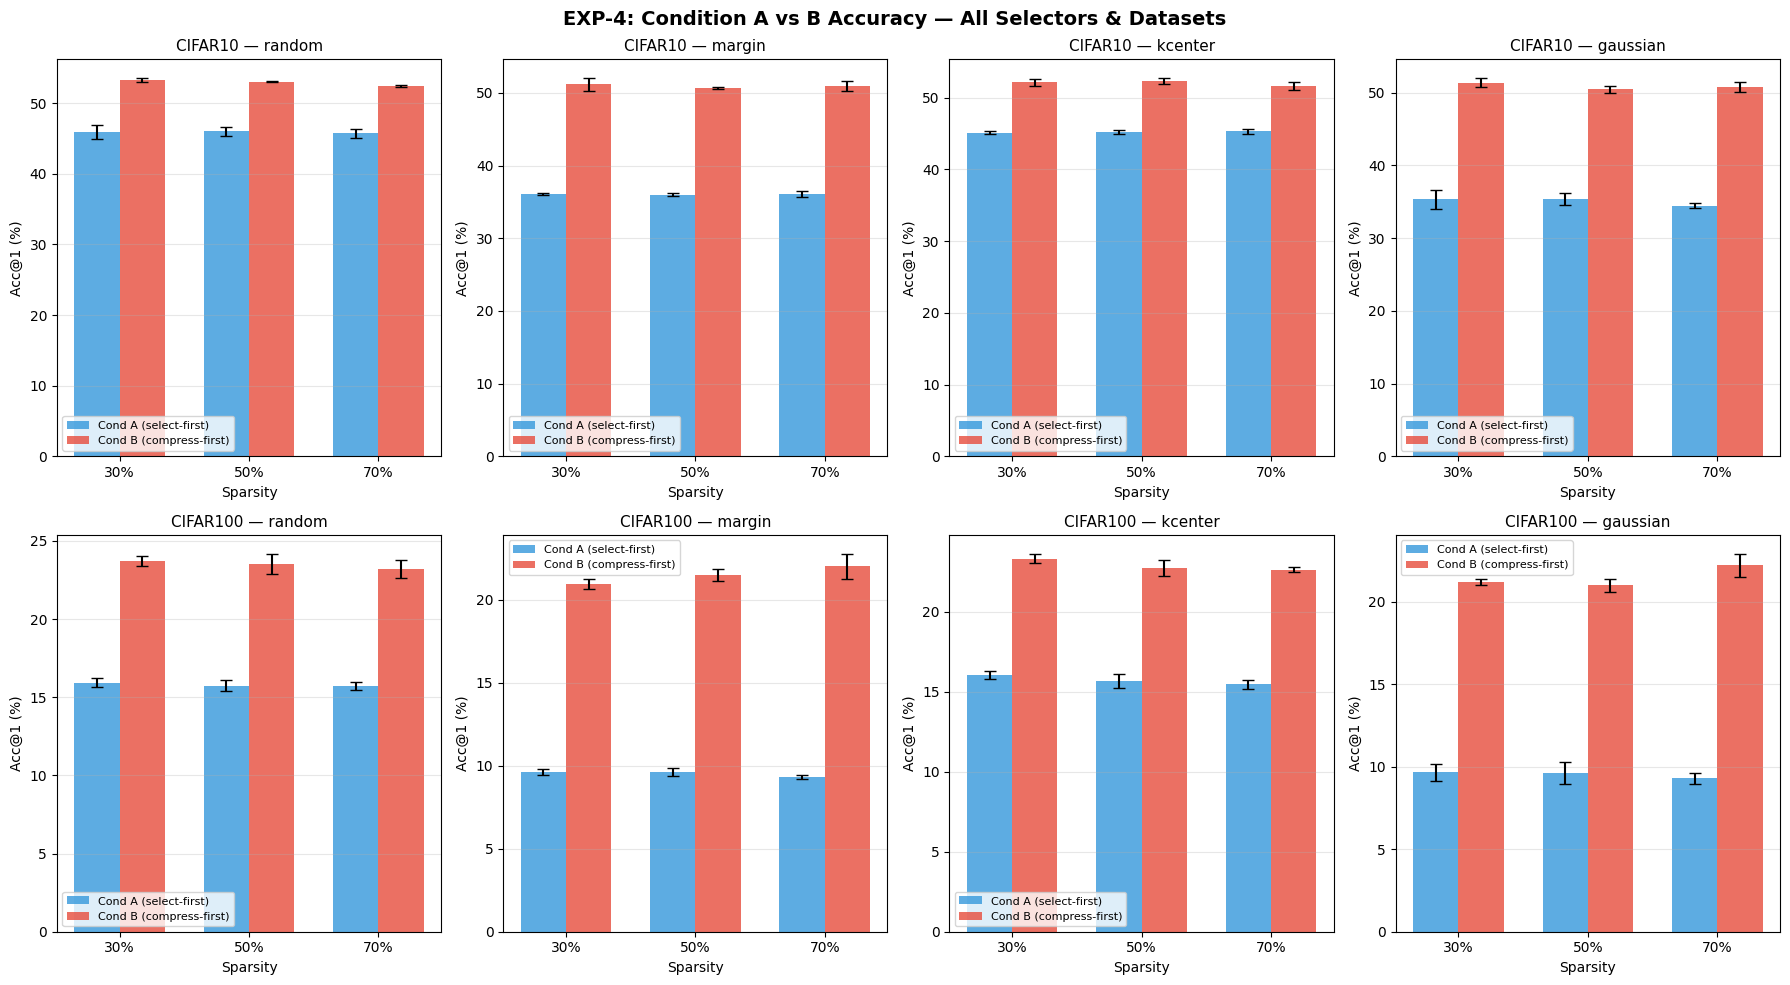

Figure 2 saved — condition A vs B bars ✓


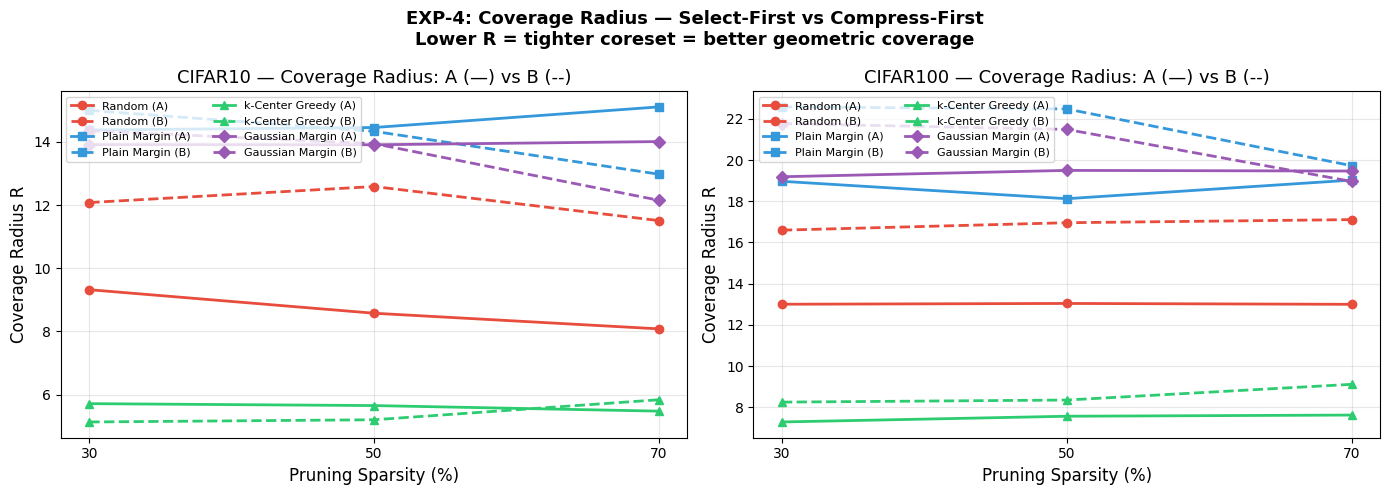

Figure 3 saved — coverage radius A vs B ✓

All figures saved to: /kaggle/working/exp4_results/figures
Cell 9 done ✓


In [10]:
# ============================================================
# EXP-4 | Cell 9 — Figures
# ============================================================
# Three figures:
# 1. Delta vs pruning rate (one line per selector) — AAAI lead figure
# 2. Condition A vs B accuracy per selector — side by side bars
# 3. Coverage radius A vs B — shows compress-first produces tighter coresets
# ============================================================

FIGURES_DIR = "/kaggle/working/exp4_results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Reload in case of kernel issues
AGG_CSV   = os.path.join(RESULTS_DIR, "exp4_aggregated.csv")
DELTA_CSV = os.path.join(RESULTS_DIR, "exp4_delta.csv")
agg       = pd.read_csv(AGG_CSV)
delta_df  = pd.read_csv(DELTA_CSV)

SELECTOR_STYLES = {
    "random"  : {"color": "#e74c3c", "marker": "o", "label": "Random"},
    "margin"  : {"color": "#3498db", "marker": "s", "label": "Plain Margin"},
    "kcenter" : {"color": "#2ecc71", "marker": "^", "label": "k-Center Greedy"},
    "gaussian": {"color": "#9b59b6", "marker": "D", "label": "Gaussian Margin"},
}

PRUNING_PCT = [30, 50, 70]

# ============================================================
# Figure 1: Delta vs pruning rate — AAAI lead figure
# Positive delta = compress-first wins
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds_name in zip(axes, ["cifar10", "cifar100"]):
    ds_delta = delta_df[delta_df["dataset"] == ds_name]

    for selector, style in SELECTOR_STYLES.items():
        rows  = ds_delta[ds_delta["selector"] == selector].sort_values("pruning_rate")
        x     = [int(r * 100) for r in rows["pruning_rate"]]
        delta = rows["delta_acc"].values
        ax.plot(x, delta,
                color=style["color"], marker=style["marker"],
                linewidth=2, markersize=7, label=style["label"])
        ax.scatter(x, delta, color=style["color"], zorder=5, s=50)

    # Zero line — above = compress-first wins
    ax.axhline(y=0, color="black", linestyle="--", linewidth=1.5,
               label="No difference")
    ax.fill_between(PRUNING_PCT, 0,
                    delta_df[delta_df["dataset"] == ds_name]["delta_acc"].max() + 1,
                    alpha=0.04, color="green", label="Compress-first wins")
    ax.fill_between(PRUNING_PCT, 0,
                    delta_df[delta_df["dataset"] == ds_name]["delta_acc"].min() - 1,
                    alpha=0.04, color="red", label="Select-first wins")

    ax.set_xlabel("Pruning Sparsity (%)", fontsize=12)
    ax.set_ylabel("Δ Acc@1 (Compress-first minus Select-first) %", fontsize=11)
    ax.set_xticks(PRUNING_PCT)
    ax.set_title(f"{ds_name.upper()} — Compress-First Advantage", fontsize=13)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

fig.suptitle("EXP-4: Order-of-Operations — Compress-First vs Select-First\n"
             "Positive = compress-first wins  |  Negative = select-first wins",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp4_delta_vs_pruning.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved — delta vs pruning rate ✓")

# ============================================================
# Figure 2: Condition A vs B accuracy bars per selector
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for row_idx, ds_name in enumerate(["cifar10", "cifar100"]):
    ds_agg = agg[agg["dataset"] == ds_name]

    for col_idx, selector in enumerate(SELECTORS):
        ax    = axes[row_idx][col_idx]
        rows_A = ds_agg[(ds_agg["selector"] == selector) &
                        (ds_agg["condition"] == "A")].sort_values("pruning_rate")
        rows_B = ds_agg[(ds_agg["selector"] == selector) &
                        (ds_agg["condition"] == "B")].sort_values("pruning_rate")

        x      = np.arange(len(PRUNING_PCT))
        width  = 0.35

        bars_A = ax.bar(x - width/2, rows_A["acc_mean"].values,
                        width, yerr=rows_A["acc_std"].values,
                        label="Cond A (select-first)",
                        color="#3498db", alpha=0.8, capsize=4)
        bars_B = ax.bar(x + width/2, rows_B["acc_mean"].values,
                        width, yerr=rows_B["acc_std"].values,
                        label="Cond B (compress-first)",
                        color="#e74c3c", alpha=0.8, capsize=4)

        ax.set_xticks(x)
        ax.set_xticklabels([f"{int(p*100)}%" for p in PRUNING_RATES])
        ax.set_xlabel("Sparsity", fontsize=10)
        ax.set_ylabel("Acc@1 (%)", fontsize=10)
        ax.set_title(f"{ds_name.upper()} — {selector}", fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("EXP-4: Condition A vs B Accuracy — All Selectors & Datasets",
             fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp4_condA_vs_condB_bars.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved — condition A vs B bars ✓")

# ============================================================
# Figure 3: Coverage radius A vs B
# Does compress-first produce tighter coresets?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ds_name in zip(axes, ["cifar10", "cifar100"]):
    ds_delta = delta_df[delta_df["dataset"] == ds_name]

    for selector, style in SELECTOR_STYLES.items():
        rows  = ds_delta[ds_delta["selector"] == selector].sort_values("pruning_rate")
        x     = [int(r * 100) for r in rows["pruning_rate"]]

        ax.plot(x, rows["R_mean_A"].values,
                color=style["color"], marker=style["marker"],
                linewidth=2, markersize=6, linestyle="-",
                label=f"{style['label']} (A)")
        ax.plot(x, rows["R_mean_B"].values,
                color=style["color"], marker=style["marker"],
                linewidth=2, markersize=6, linestyle="--",
                label=f"{style['label']} (B)")

    ax.set_xlabel("Pruning Sparsity (%)", fontsize=12)
    ax.set_ylabel("Coverage Radius R", fontsize=12)
    ax.set_xticks(PRUNING_PCT)
    ax.set_title(f"{ds_name.upper()} — Coverage Radius: A (—) vs B (--)", fontsize=13)
    ax.legend(fontsize=8, loc="upper left", ncol=2)
    ax.grid(True, alpha=0.3)

fig.suptitle("EXP-4: Coverage Radius — Select-First vs Compress-First\n"
             "Lower R = tighter coreset = better geometric coverage",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp4_coverage_radius.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved — coverage radius A vs B ✓")

print(f"\nAll figures saved to: {FIGURES_DIR}")
print("Cell 9 done ✓")

In [11]:
# ============================================================
# EXP-4 | Cell 10 — Save Everything & Summary
# ============================================================

import shutil
import zipfile
import json

SAVE_DIR = "/kaggle/working/exp4_final"
os.makedirs(SAVE_DIR, exist_ok=True)

# Ensure paths defined
AGG_CSV     = os.path.join(RESULTS_DIR, "exp4_aggregated.csv")
DELTA_CSV   = os.path.join(RESULTS_DIR, "exp4_delta.csv")
FIGURES_DIR = "/kaggle/working/exp4_results/figures"

# ── 1. Copy CSVs ──
shutil.copy(RESULTS_CSV, os.path.join(SAVE_DIR, "exp4_runs.csv"))
shutil.copy(AGG_CSV,     os.path.join(SAVE_DIR, "exp4_aggregated.csv"))
shutil.copy(DELTA_CSV,   os.path.join(SAVE_DIR, "exp4_delta.csv"))
print("CSVs copied ✓")

# ── 2. Copy figures ──
for fname in os.listdir(FIGURES_DIR):
    if fname.endswith(".png"):
        shutil.copy(os.path.join(FIGURES_DIR, fname),
                    os.path.join(SAVE_DIR, fname))
print("Figures copied ✓")

# ── 3. Copy coreset indices ──
SAVE_CORESETS = os.path.join(SAVE_DIR, "coresets")
os.makedirs(SAVE_CORESETS, exist_ok=True)
for fname in os.listdir(CORESET_DIR):
    if fname.endswith(".npy"):
        shutil.copy(os.path.join(CORESET_DIR, fname),
                    os.path.join(SAVE_CORESETS, fname))
n_coresets = len(os.listdir(SAVE_CORESETS))
print(f"Coreset indices copied ✓ ({n_coresets} files)")

# ── 4. Copy FP models ──
SAVE_FP = os.path.join(SAVE_DIR, "fp_models")
os.makedirs(SAVE_FP, exist_ok=True)
for fname in os.listdir(FP_MODEL_DIR):
    shutil.copy(os.path.join(FP_MODEL_DIR, fname),
                os.path.join(SAVE_FP, fname))
n_fp = len(os.listdir(SAVE_FP))
print(f"FP models copied ✓ ({n_fp} files)")

# ── 5. Save config JSON ──
config = {
    "experiment"      : "EXP-4",
    "description"     : "Order-of-operations: select-first (A) vs compress-first (B)",
    "novel_contribution": "Tests whether coreset selection in compressed embedding space outperforms selection in full-precision space — not addressed by [1][2][3]",
    "papers"          : {
        "[1]": "Sener & Savarese ICLR 2018 — k-center greedy",
        "[2]": "Geifman & El-Yaniv NeurIPS 2017 — embedding quality drives selector quality",
        "[3]": "Bahri et al. 2022 — coreset gap under compression"
    },
    "datasets"        : ["cifar10", "cifar100"],
    "selectors"       : SELECTORS,
    "pruning_rates"   : PRUNING_RATES,
    "seeds"           : SEEDS,
    "coreset_size"    : CORESET_SIZE,
    "condition_A"     : "select coreset on full-precision embeddings → train 40 epochs → prune → finetune 10 epochs",
    "condition_B"     : "train full 50k → prune → select coreset on compressed embeddings → finetune 20 epochs",
    "mlp_arch"        : "FC-512-BN-ReLU-Drop → FC-256-BN-ReLU-Drop → FC-128-BN-ReLU → output",
    "mlp_params"      : 1740682,
    "optimizer"       : "Adam lr=0.001 wd=0.0001 batch=256 StepLR(step=15 gamma=0.1)",
    "pruning_method"  : "magnitude-based unstructured (PyTorch l1_unstructured)",
}
with open(os.path.join(SAVE_DIR, "exp4_config.json"), "w") as f:
    json.dump(config, f, indent=2)
print("Config JSON saved ✓")

# ── 6. Final summary ──
df       = pd.read_csv(RESULTS_CSV)
agg      = pd.read_csv(AGG_CSV)
delta_df = pd.read_csv(DELTA_CSV)

print("\n" + "="*75)
print("EXP-4 FINAL SUMMARY")
print("="*75)
print(f"Total runs logged  : {len(df)}")
print(f"Condition A runs   : {len(df[df['condition'] == 'A'])}")
print(f"Condition B runs   : {len(df[df['condition'] == 'B'])}")
print(f"Seeds per condition: {len(SEEDS)}")

for ds_name in ["cifar10", "cifar100"]:
    print(f"\n  {ds_name.upper()} — Delta Summary (Compress-first advantage)")
    print(f"  {'Selector':>10} │ {'p=30%':>8} │ {'p=50%':>8} │ {'p=70%':>8} │ {'Mean Δ':>8} │ {'Winner':>12}")
    print(f"  {'-'*10}─┼─{'-'*8}─┼─{'-'*8}─┼─{'-'*8}─┼─{'-'*8}─┼─{'-'*12}")
    ds_delta = delta_df[delta_df["dataset"] == ds_name]
    for selector in SELECTORS:
        rows   = ds_delta[ds_delta["selector"] == selector].sort_values("pruning_rate")
        deltas = rows["delta_acc"].values
        d30    = f"{deltas[0]:+.2f}%" if len(deltas) > 0 else "N/A"
        d50    = f"{deltas[1]:+.2f}%" if len(deltas) > 1 else "N/A"
        d70    = f"{deltas[2]:+.2f}%" if len(deltas) > 2 else "N/A"
        mean_d = deltas.mean() if len(deltas) > 0 else 0
        winner = "compress-first" if mean_d > 0 else "select-first"
        print(f"  {selector:>10} │ {d30:>8} │ {d50:>8} │ {d70:>8} │ "
              f"{mean_d:>+7.2f}% │ {winner:>12}")

# ── Interaction law — fill in from results ──
print("\n" + "="*75)
print("INTERACTION LAW (fill X and Y for D4 report §Discussion)")
print("="*75)
for ds_name in ["cifar10", "cifar100"]:
    ds_delta = delta_df[delta_df["dataset"] == ds_name]
    kc_rows  = ds_delta[ds_delta["selector"] == "kcenter"].sort_values("pruning_rate")
    best_delta = kc_rows["delta_acc"].max()
    best_rate  = int(kc_rows.loc[kc_rows["delta_acc"].idxmax(), "pruning_rate"] * 100)
    print(f"\n  {ds_name.upper()} — k-Center (strongest geometry-aware selector):")
    print(f"  Best compress-first advantage: {best_delta:+.2f}% at {best_rate}% sparsity")
    print(f"  → Plug into interaction law: X={best_rate}, Y={best_delta:.2f}")

# ── 7. Zip for download ──
ZIP_PATH = "/kaggle/working/EXP4_results.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(SAVE_DIR):
        for file in files:
            fpath   = os.path.join(root, file)
            arcname = os.path.relpath(fpath, SAVE_DIR)
            zf.write(fpath, arcname)
zip_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f"\nZip created : EXP4_results.zip ({zip_mb:.1f} MB)")
print(f"Download from: /kaggle/working/EXP4_results.zip")
print("\nEXP-4 COMPLETE ✓")
print("="*75)

CSVs copied ✓
Figures copied ✓
Coreset indices copied ✓ (144 files)
FP models copied ✓ (12 files)
Config JSON saved ✓

EXP-4 FINAL SUMMARY
Total runs logged  : 144
Condition A runs   : 72
Condition B runs   : 72
Seeds per condition: 3

  CIFAR10 — Delta Summary (Compress-first advantage)
    Selector │    p=30% │    p=50% │    p=70% │   Mean Δ │       Winner
  ----------─┼─--------─┼─--------─┼─--------─┼─--------─┼─------------
      random │   +7.34% │   +7.06% │   +6.70% │   +7.03% │ compress-first
      margin │  +15.04% │  +14.70% │  +14.96% │  +14.90% │ compress-first
     kcenter │   +6.99% │   +7.10% │   +6.33% │   +6.81% │ compress-first
    gaussian │  +16.05% │  +15.08% │  +16.27% │  +15.80% │ compress-first

  CIFAR100 — Delta Summary (Compress-first advantage)
    Selector │    p=30% │    p=50% │    p=70% │   Mean Δ │       Winner
  ----------─┼─--------─┼─--------─┼─--------─┼─--------─┼─------------
      random │   +7.79% │   +7.78% │   +7.47% │   +7.68% │ compress-firs